### Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/Phishing_Dataset.csv")

In [ ]:
df_raw = df.copy();

In [ ]:
# create working copy
df = df_raw.copy()

### Data Understanding

In [4]:

print(df.shape)
print(df.head())

(235795, 55)
                                  URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0  org               100.0              1.000000   

   TLDLegitimateProb  URLCharProb  ..

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

In [6]:
df.columns

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

In [7]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


### Data validation

In [8]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [11]:
df.dtypes

URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode                      int64
LargestLineL

In [12]:
df.nunique().sort_values()

IsDomainIP                         2
HasObfuscation                     2
HasFavicon                         2
HasTitle                           2
IsHTTPS                            2
HasHiddenFields                    2
Pay                                2
Bank                               2
HasSocialNet                       2
HasSubmitButton                    2
HasExternalFormSubmit              2
HasDescription                     2
NoOfSelfRedirect                   2
NoOfURLRedirect                    2
IsResponsive                       2
Robots                             2
HasPasswordField                   2
label                              2
HasCopyrightInfo                   2
Crypto                             2
NoOfQMarkInURL                     5
NoOfSubDomain                     10
TLDLength                         12
NoOfObfuscatedChar                20
NoOfEqualsInURL                   25
NoOfAmpersandInURL                31
NoOfOtherSpecialCharsInURL        74
D

In [13]:
df.nunique()[df.nunique() == 1]

Series([], dtype: int64)

In [14]:
df["label"].unique()

array([1, 0])

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["URL"].duplicated().sum()

np.int64(425)

In [17]:
df["Domain"].duplicated().sum()

np.int64(15709)

In [2]:
import numpy as np

np.isinf(df.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

### Data analysis

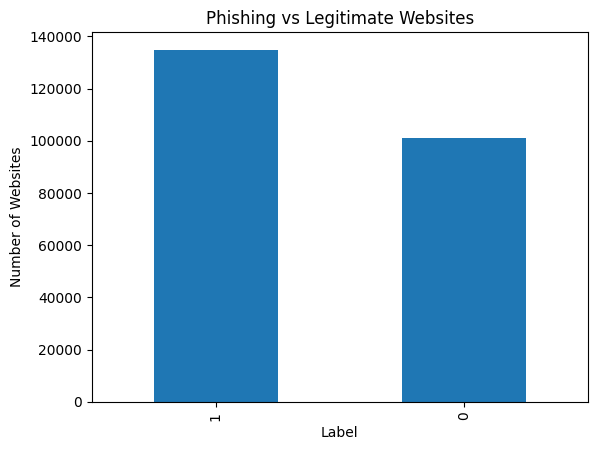

In [19]:
import matplotlib.pyplot as plt
label_count = df["label"].value_counts()

label_count.plot(kind = "bar")

plt.title("Phishing vs Legitimate Websites")
plt.xlabel("Label")
plt.ylabel("Number of Websites")
plt.show()

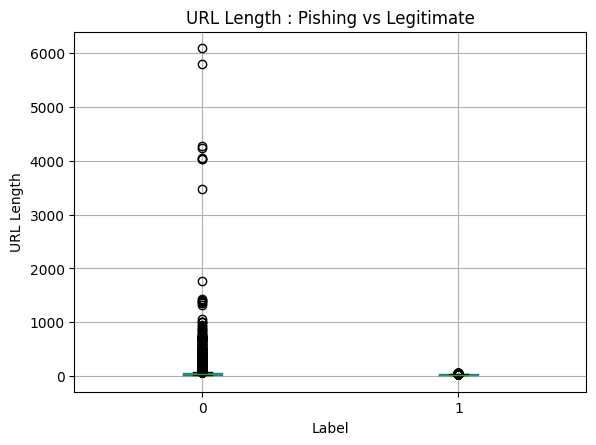

In [4]:
df.boxplot(column= "URLLength", by="label")

plt.title("URL Length : Pishing vs Legitimate")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("URL Length")
plt.show()

In [5]:
df.groupby("label")["URLLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,45.720293,61.145523,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


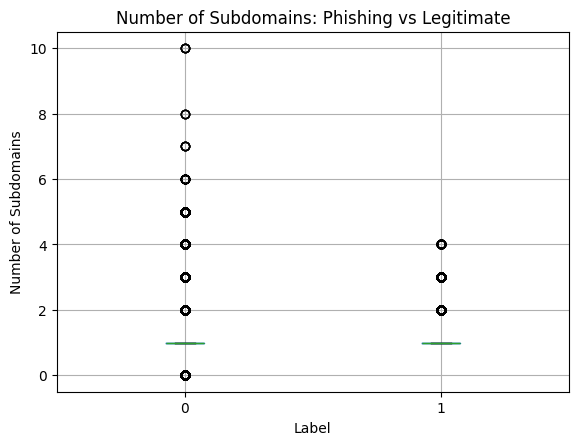

In [6]:
df.boxplot(column="NoOfSubDomain", by="label")

plt.title("Number of Subdomains: Phishing vs Legitimate")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Number of Subdomains")
plt.show()

In [7]:
df.groupby("label")["NoOfSubDomain"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,1.168894,0.790880,0.0,1.0,1.0,1.0,10.0
1,134850.0,1.161661,0.404076,1.0,1.0,1.0,1.0,4.0


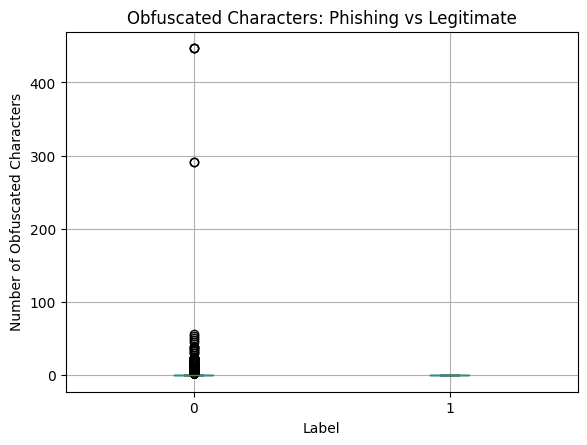

In [8]:
df.boxplot(column="NoOfObfuscatedChar", by="label")

plt.title("Obfuscated Characters: Phishing vs Legitimate")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Number of Obfuscated Characters")
plt.show()

In [9]:
df.groupby("label")["NoOfObfuscatedChar"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,0.058071,2.867251,0.0,0.0,0.0,0.0,447.0
1,134850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [10]:
correlation = df.corr(numeric_only=True)["label"].sort_values()

correlation

SpacialCharRatioInURL        -0.533537
DegitRatioInURL              -0.432032
LetterRatioInURL             -0.367794
NoOfOtherSpecialCharsInURL   -0.358891
DomainLength                 -0.283152
NoOfLettersInURL             -0.258090
URLLength                    -0.233445
NoOfDegitsInURL              -0.177980
NoOfQMarkInURL               -0.175621
TLDLength                    -0.079159
NoOfEqualsInURL              -0.076963
NoOfSelfRedirect             -0.076463
IsDomainIP                   -0.060202
HasObfuscation               -0.052473
NoOfURLRedirect              -0.046456
ObfuscationRatio             -0.041915
LargestLineLength            -0.041111
NoOfAmpersandInURL           -0.034622
NoOfObfuscatedChar           -0.015315
NoOfSubDomain                -0.005955
NoOfPopup                     0.047391
NoOfCSS                       0.068109
TLDLegitimateProb             0.097389
Crypto                        0.099610
NoOfEmptyRef                  0.109235
HasPasswordField         

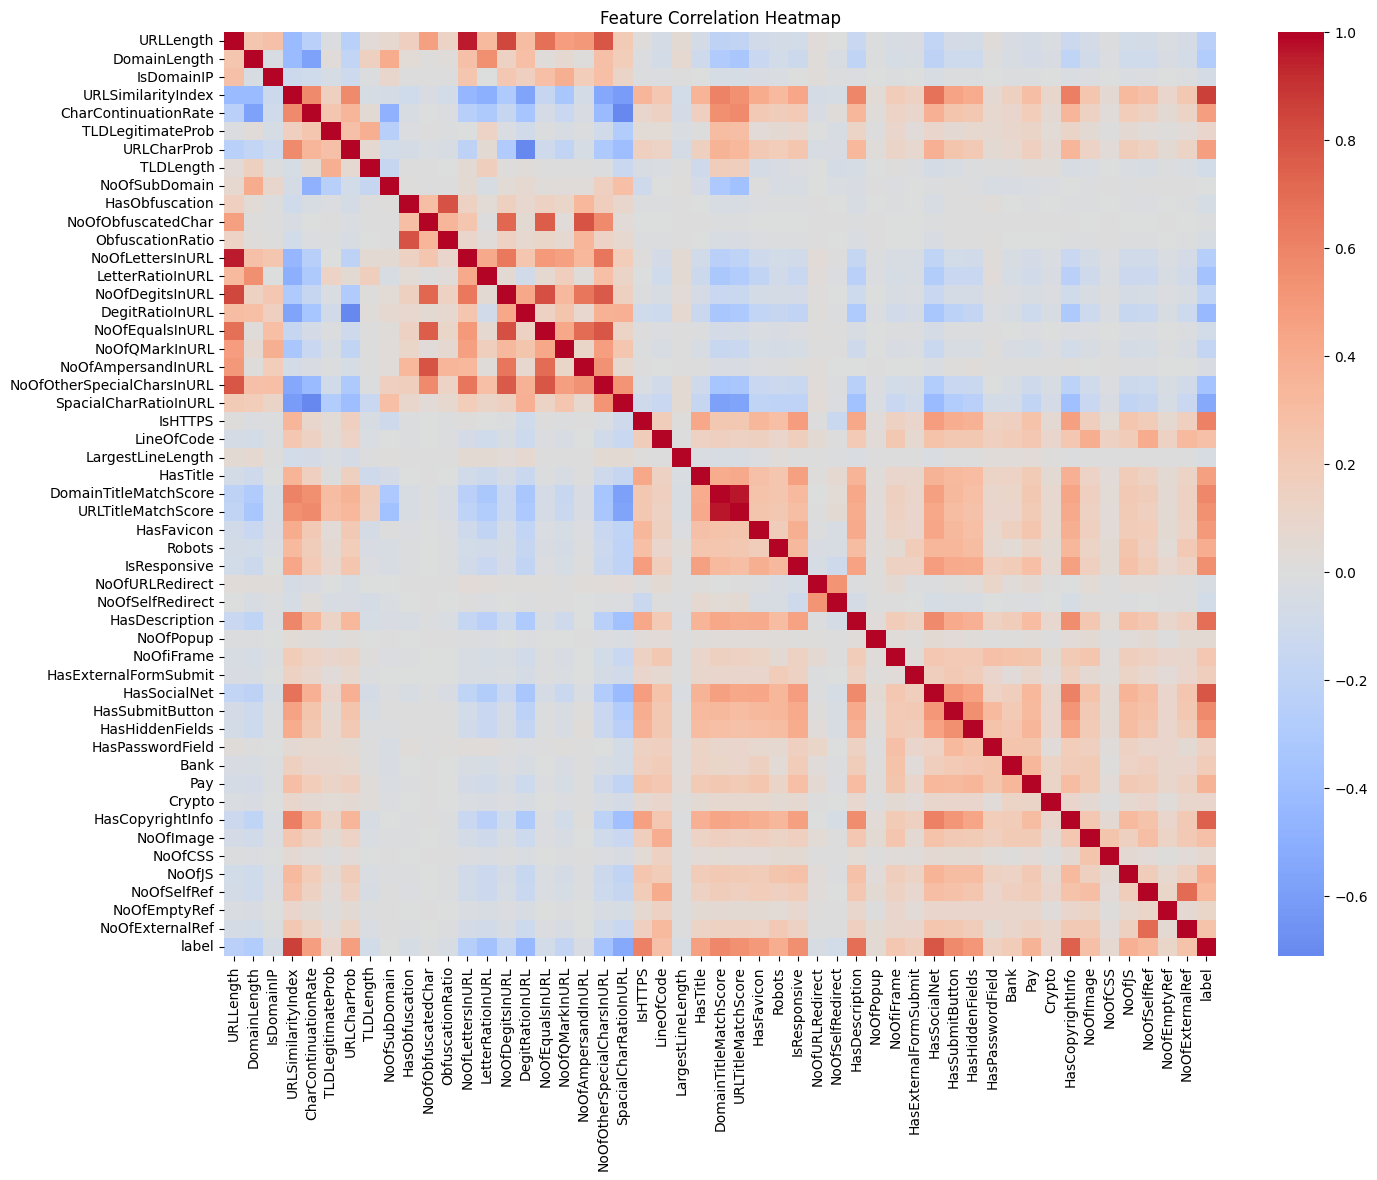

In [13]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [14]:
corr_matrix = df.corr(numeric_only=True)

high_corr = (
    corr_matrix.where(
        (corr_matrix.abs() >= 0.80) & (corr_matrix.abs() < 1)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

high_corr

DomainTitleMatchScore  URLTitleMatchScore       0.961008
URLTitleMatchScore     DomainTitleMatchScore    0.961008
NoOfLettersInURL       URLLength                0.956047
URLLength              NoOfLettersInURL         0.956047
label                  URLSimilarityIndex       0.860358
URLSimilarityIndex     label                    0.860358
URLLength              NoOfDegitsInURL          0.835809
NoOfDegitsInURL        URLLength                0.835809
                       NoOfEqualsInURL          0.806024
NoOfEqualsInURL        NoOfDegitsInURL          0.806024
dtype: float64

In [15]:
high_corr_pairs = (
    corr_matrix.where(
        (corr_matrix.abs() >= 0.80) & (corr_matrix.abs() < 1)
    )
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr_pairs

,Feature 1,Feature 2,Correlation
0,URLLength,NoOfLettersInURL,0.956047
1,URLLength,NoOfDegitsInURL,0.835809
2,URLSimilarityIndex,label,0.860358
3,NoOfLettersInURL,URLLength,0.956047
4,NoOfDegitsInURL,URLLength,0.835809
5,NoOfDegitsInURL,NoOfEqualsInURL,0.806024
6,NoOfEqualsInURL,NoOfDegitsInURL,0.806024
7,DomainTitleMatchScore,URLTitleMatchScore,0.961008
8,URLTitleMatchScore,DomainTitleMatchScore,0.961008
9,label,URLSimilarityIndex,0.860358


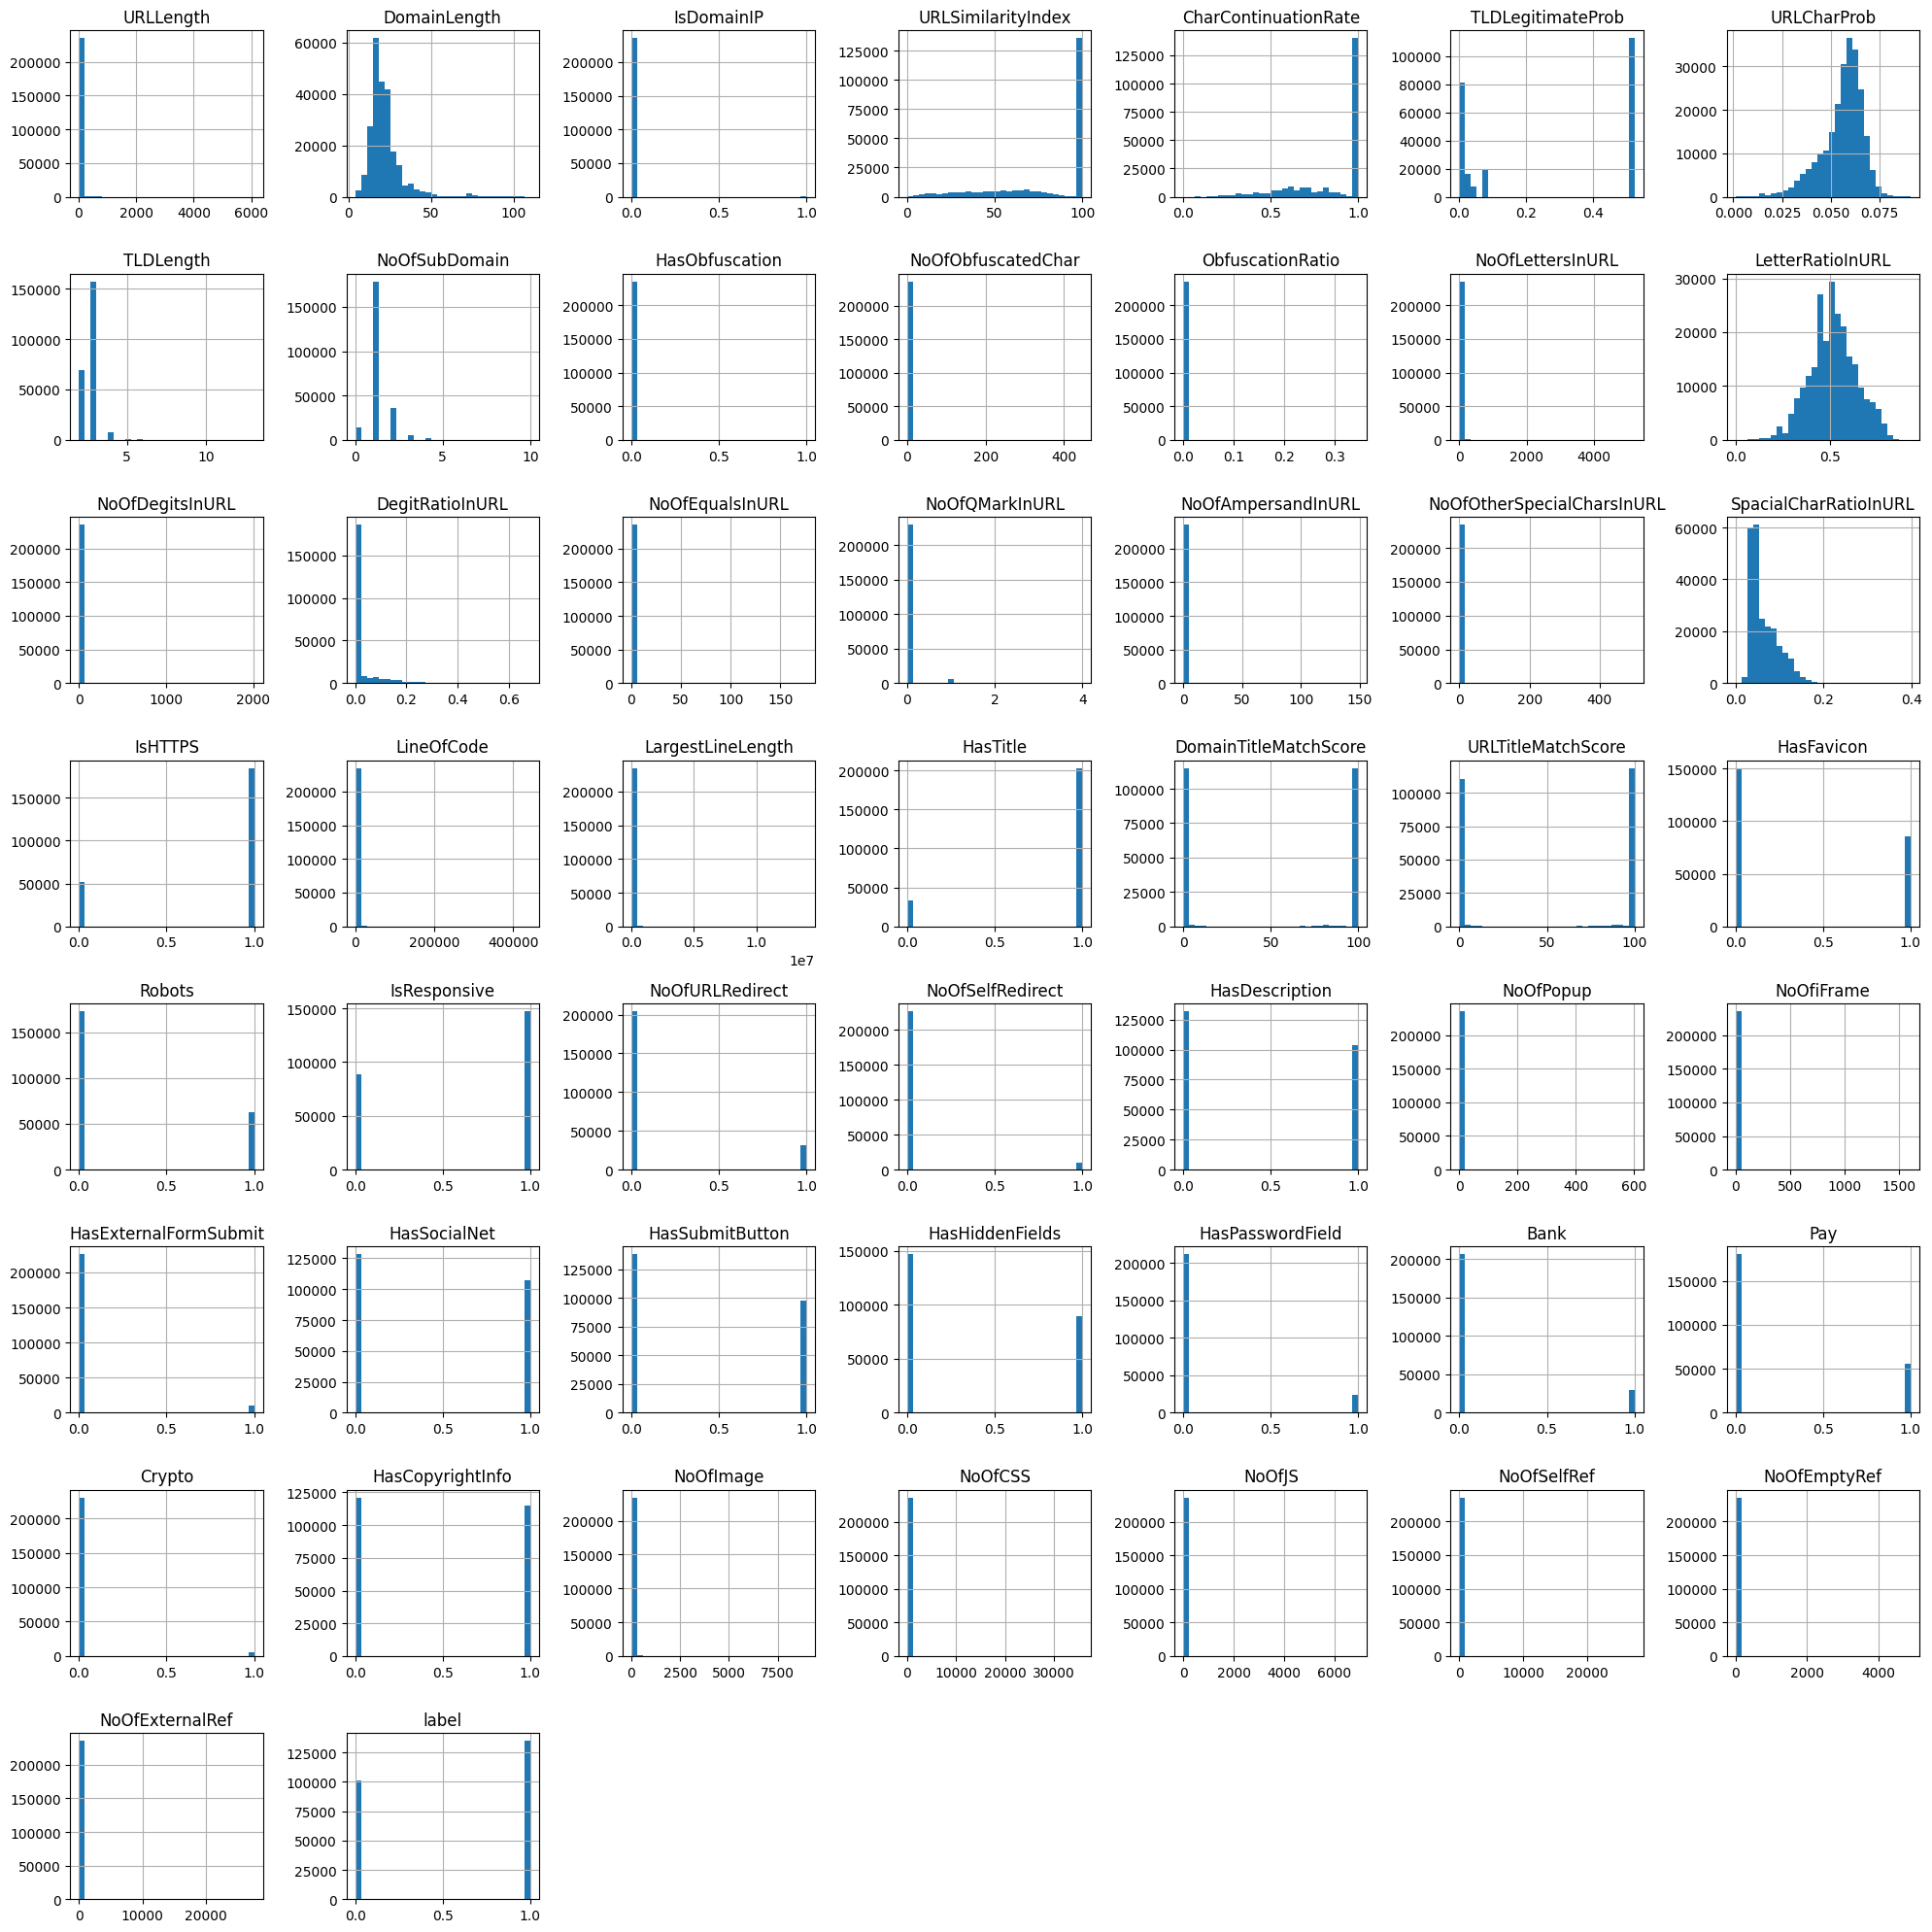

In [16]:
df.hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()

In [6]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)

skewness

NoOfCSS                       464.404031
NoOfObfuscatedChar            204.684335
NoOfJS                        140.435761
NoOfEqualsInURL               114.985479
NoOfEmptyRef                  106.826225
NoOfAmpersandInURL            106.717256
NoOfiFrame                     97.677347
NoOfDegitsInURL                94.877574
NoOfPopup                      84.952694
NoOfExternalRef                65.900247
NoOfSelfRef                    60.381378
NoOfLettersInURL               58.402581
URLLength                      53.321737
LineOfCode                     53.072297
LargestLineLength              48.179926
NoOfOtherSpecialCharsInURL     47.428522
ObfuscationRatio               40.118612
NoOfImage                      28.230253
HasObfuscation                 21.981435
IsDomainIP                     19.146593
NoOfQMarkInURL                  8.160618
Crypto                          6.294860
NoOfSelfRedirect                4.687797
HasExternalFormSubmit           4.447479
DegitRatioInURL 

In [7]:
skewed_features = skewness[
    (skewness.abs() > 1) &
    (df[skewness.index].nunique() > 2)
]

skewed_features

NoOfCSS                       464.404031
NoOfObfuscatedChar            204.684335
NoOfJS                        140.435761
NoOfEqualsInURL               114.985479
NoOfEmptyRef                  106.826225
NoOfAmpersandInURL            106.717256
NoOfiFrame                     97.677347
NoOfDegitsInURL                94.877574
NoOfPopup                      84.952694
NoOfExternalRef                65.900247
NoOfSelfRef                    60.381378
NoOfLettersInURL               58.402581
URLLength                      53.321737
LineOfCode                     53.072297
LargestLineLength              48.179926
NoOfOtherSpecialCharsInURL     47.428522
ObfuscationRatio               40.118612
NoOfImage                      28.230253
NoOfQMarkInURL                  8.160618
DegitRatioInURL                 3.244523
DomainLength                    2.513397
NoOfSubDomain                   1.809400
TLDLength                       1.663518
SpacialCharRatioInURL           1.184134
URLCharProb     

In [3]:
df.isnull().sum().sort_values(ascending=False)

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [3]:
X = df.drop("label", axis=1)
y = df["label"]

print(X.shape)
print(y.shape)

(235795, 54)
(235795,)


In [8]:
skewed_cols = [
    col for col in skewed_features.index
    if X[col].nunique() > 2
]

In [9]:
X[skewed_cols] = np.log1p(X[skewed_cols])

In [10]:
skewed_cols

['NoOfCSS',
 'NoOfObfuscatedChar',
 'NoOfJS',
 'NoOfEqualsInURL',
 'NoOfEmptyRef',
 'NoOfAmpersandInURL',
 'NoOfiFrame',
 'NoOfDegitsInURL',
 'NoOfPopup',
 'NoOfExternalRef',
 'NoOfSelfRef',
 'NoOfLettersInURL',
 'URLLength',
 'LineOfCode',
 'LargestLineLength',
 'NoOfOtherSpecialCharsInURL',
 'ObfuscationRatio',
 'NoOfImage',
 'NoOfQMarkInURL',
 'DegitRatioInURL',
 'DomainLength',
 'NoOfSubDomain',
 'TLDLength',
 'SpacialCharRatioInURL',
 'URLCharProb',
 'CharContinuationRate']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (188636, 54)
X_test: (47159, 54)
y_train: (188636,)
y_test: (47159,)


In [13]:
print("Training feature data types:")
print(X_train.dtypes.value_counts())

print("\nNon-numerical columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("Is label in X_train?", "label" in X_train.columns)
print("Is label in X_test?", "label" in X_test.columns)

Training feature data types:
float64    31
int64      19
object      4
Name: count, dtype: int64

Non-numerical columns:
['URL', 'Domain', 'TLD', 'Title']
Is label in X_train? False
Is label in X_test? False


In [14]:
X_train_num = X_train.select_dtypes(include="number").copy()
X_test_num = X_test.select_dtypes(include="number").copy()

print("Training features:", X_train_num.shape)
print("Testing features:", X_test_num.shape)

Training features: (188636, 50)
Testing features: (47159, 50)
